## Data Understanding

### Dataset Overview

In [10]:
import pandas as pd 

%time df = pd.read_csv("../data/train.csv", delimiter=',')

CPU times: total: 312 ms
Wall time: 355 ms


In [ ]:
# from ydata_profiling import ProfileReport

# profile = ProfileReport(df, title="Data Understanding")
# profile.to_file("data_understanding_report.html")

In [11]:
df.sample(5)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
81162,81162,Sanket,Male,55.0,Nashik,Working Professional,Customer Support,NaN,1.0,NaN,NaN,1.0,More than 8 hours,Healthy,BA,Yes,1.0,2.0,Yes,0
95579,95579,Rupak,Male,56.0,Delhi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,7-8 hours,Healthy,LLM,Yes,2.0,2.0,Yes,0
131758,131758,Pallavi,Female,49.0,Nashik,Working Professional,Pharmacist,NaN,5.0,NaN,NaN,3.0,More than 8 hours,Healthy,MBBS,No,10.0,2.0,Yes,0
76456,76456,Raghav,Male,36.0,Kanpur,Working Professional,Marketing Manager,NaN,5.0,NaN,NaN,4.0,7-8 hours,Healthy,B.Com,No,10.0,3.0,No,0
114879,114879,Ayaan,Male,26.0,Visakhapatnam,Student,NaN,2.0,NaN,9.37,1.0,NaN,7-8 hours,Unhealthy,BSc,Yes,12.0,5.0,No,1


In [12]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


In [13]:
total = df.isnull().sum().sort_values(ascending=False)

percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)

missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Missing Percent'])

In [14]:
missing_data['Missing Percent'] = missing_data['Missing Percent'].apply(lambda x: x*100)
missing_data.loc[missing_data['Missing Percent'] > 10][:10]

,Total,Missing Percent
Study Satisfaction,112803,80.172708
Academic Pressure,112803,80.172708
CGPA,112802,80.171997
Profession,36630,26.034115
Work Pressure,27918,19.842217
Job Satisfaction,27910,19.836532


In [15]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [20]:
numerical_vars = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction',
                  'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

categorical_vars = ['Gender', 'Working Professional or Student', 'Sleep Duration', 'Dietary Habits', 
                    'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

In [21]:
df = df[numerical_vars+categorical_vars]

In [22]:
df.shape

(140700, 14)

In [24]:
df[numerical_vars].describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
count,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000
mean,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983
std,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633
min,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000
25%,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000
50%,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000
75%,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000
max,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Academic Pressure'}>],
       [<Axes: title={'center': 'Work Pressure'}>,
        <Axes: title={'center': 'CGPA'}>],
       [<Axes: title={'center': 'Study Satisfaction'}>,
        <Axes: title={'center': 'Job Satisfaction'}>],
       [<Axes: title={'center': 'Work/Study Hours'}>,
        <Axes: title={'center': 'Financial Stress'}>]], dtype=object)

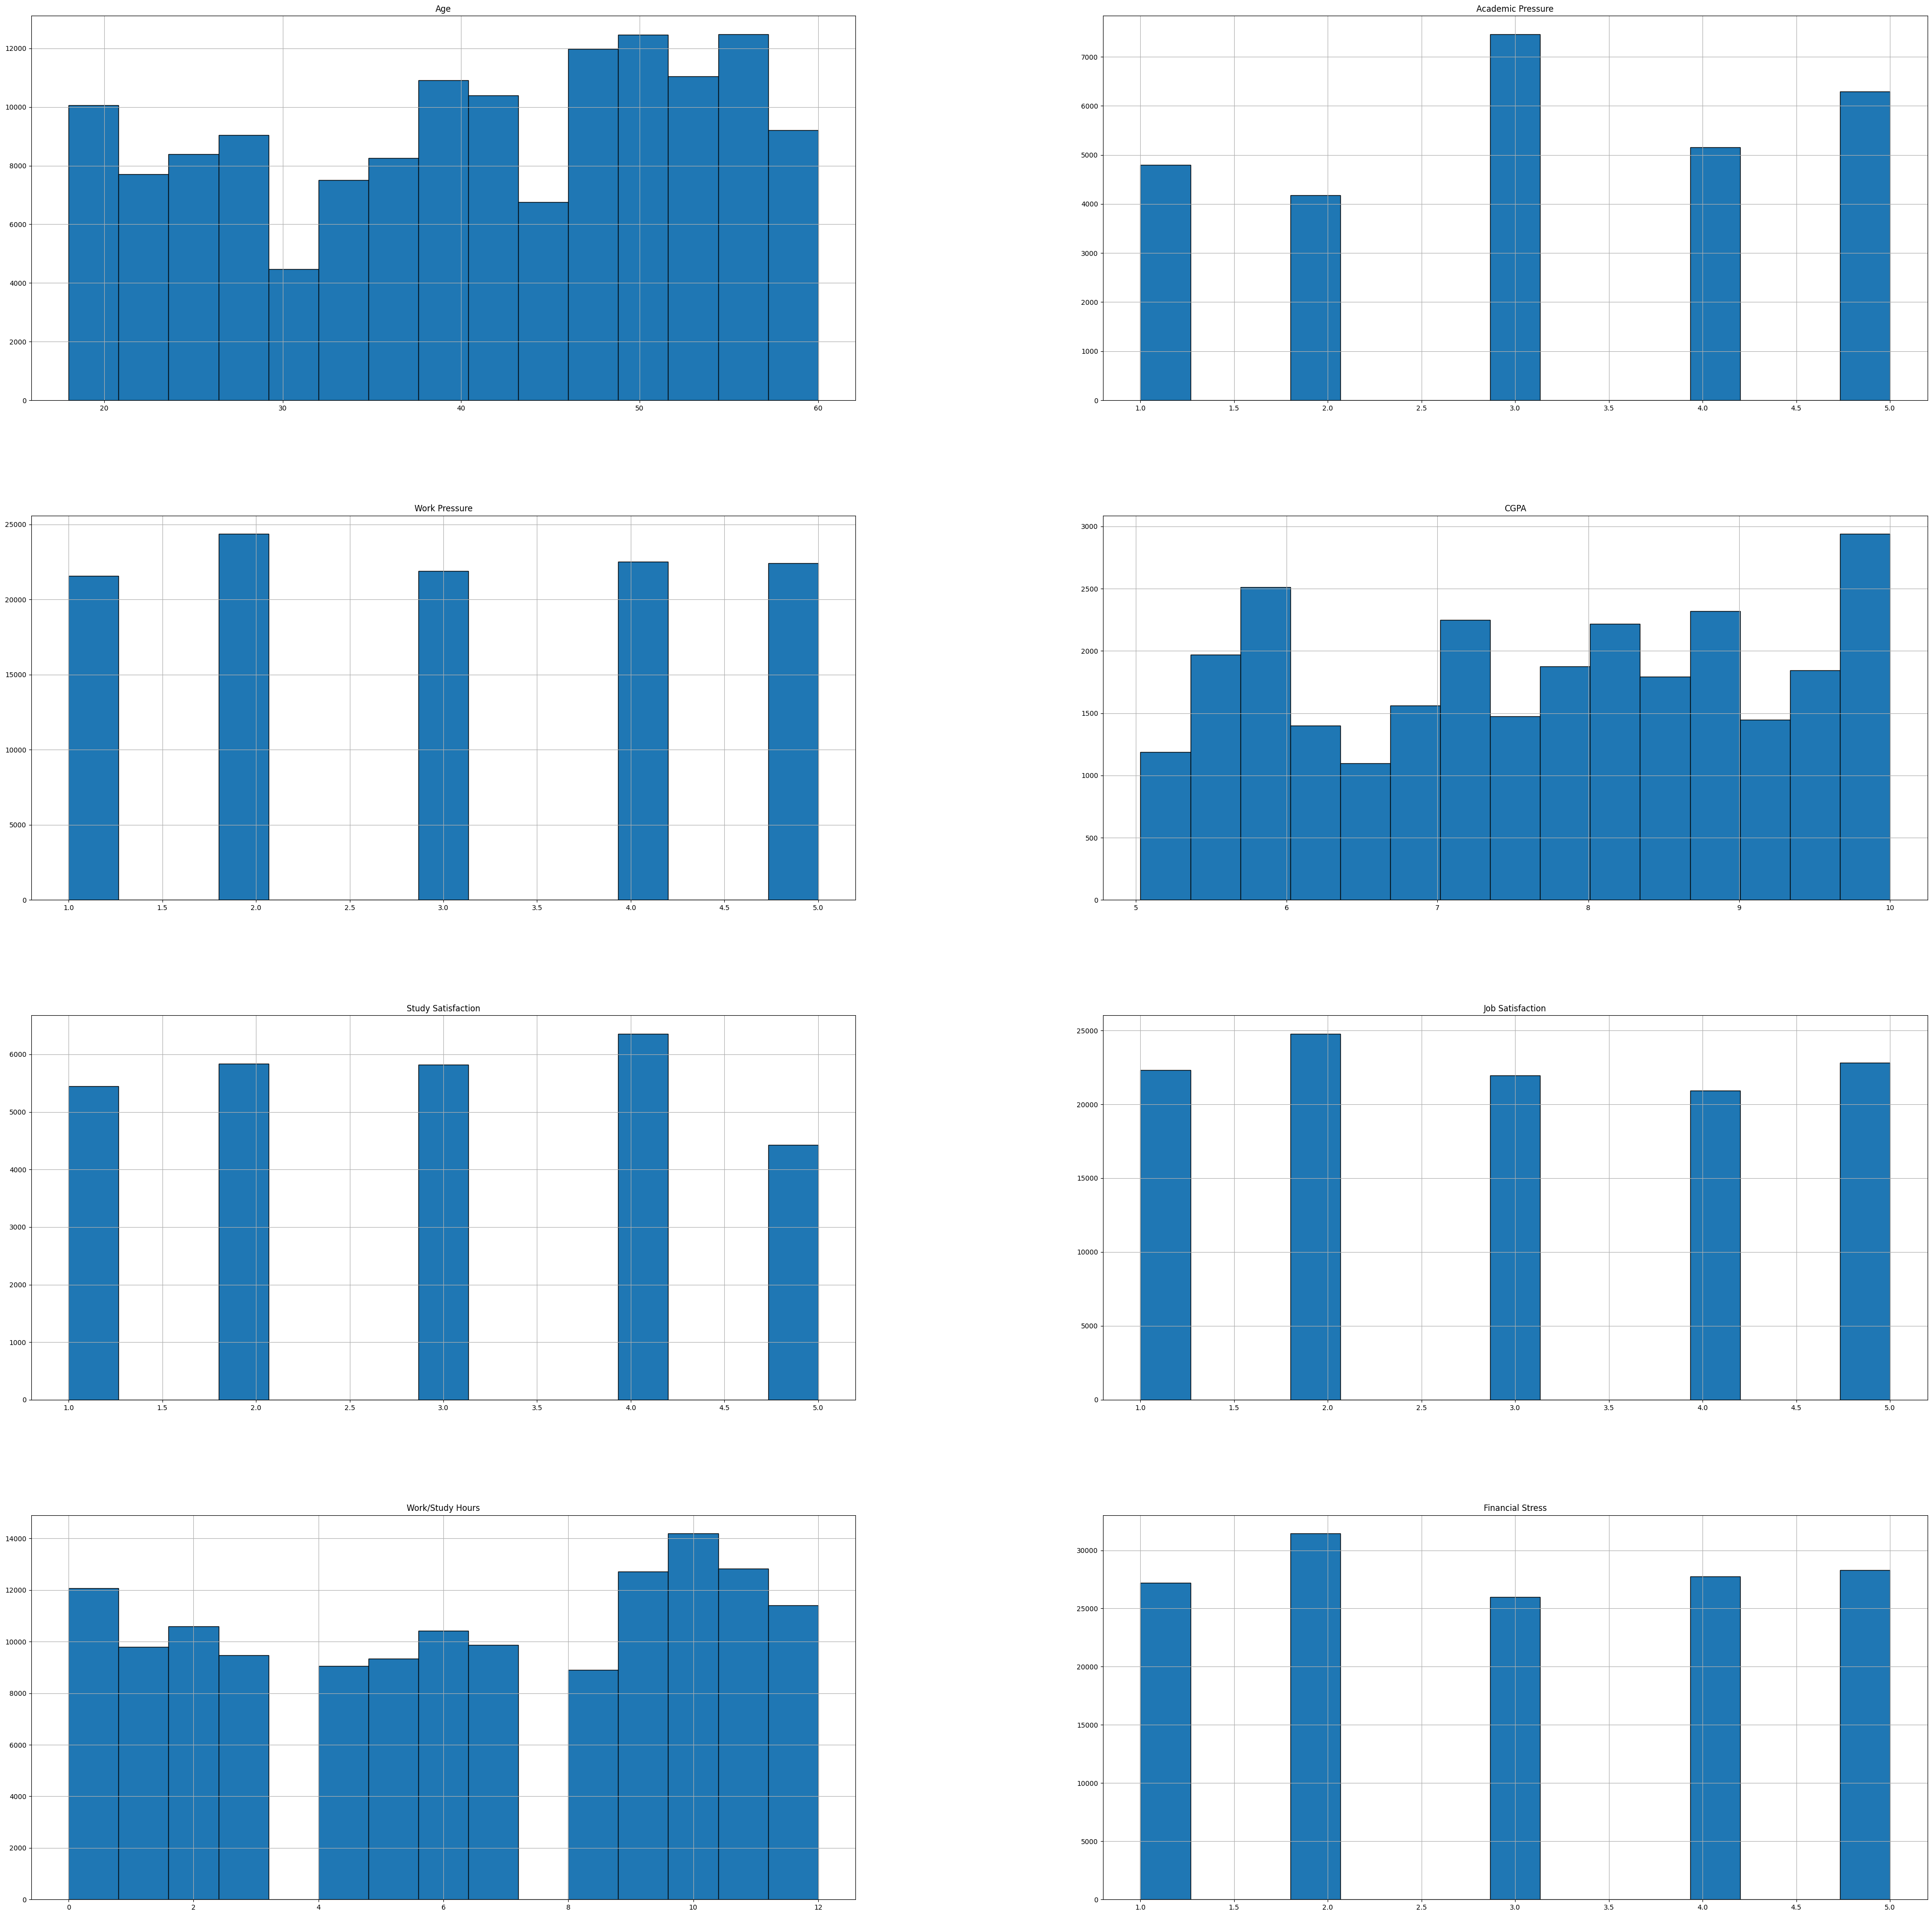

In [28]:
df[numerical_vars].hist(edgecolor='black', bins=15, figsize=(50, 50), layout=(4,2))

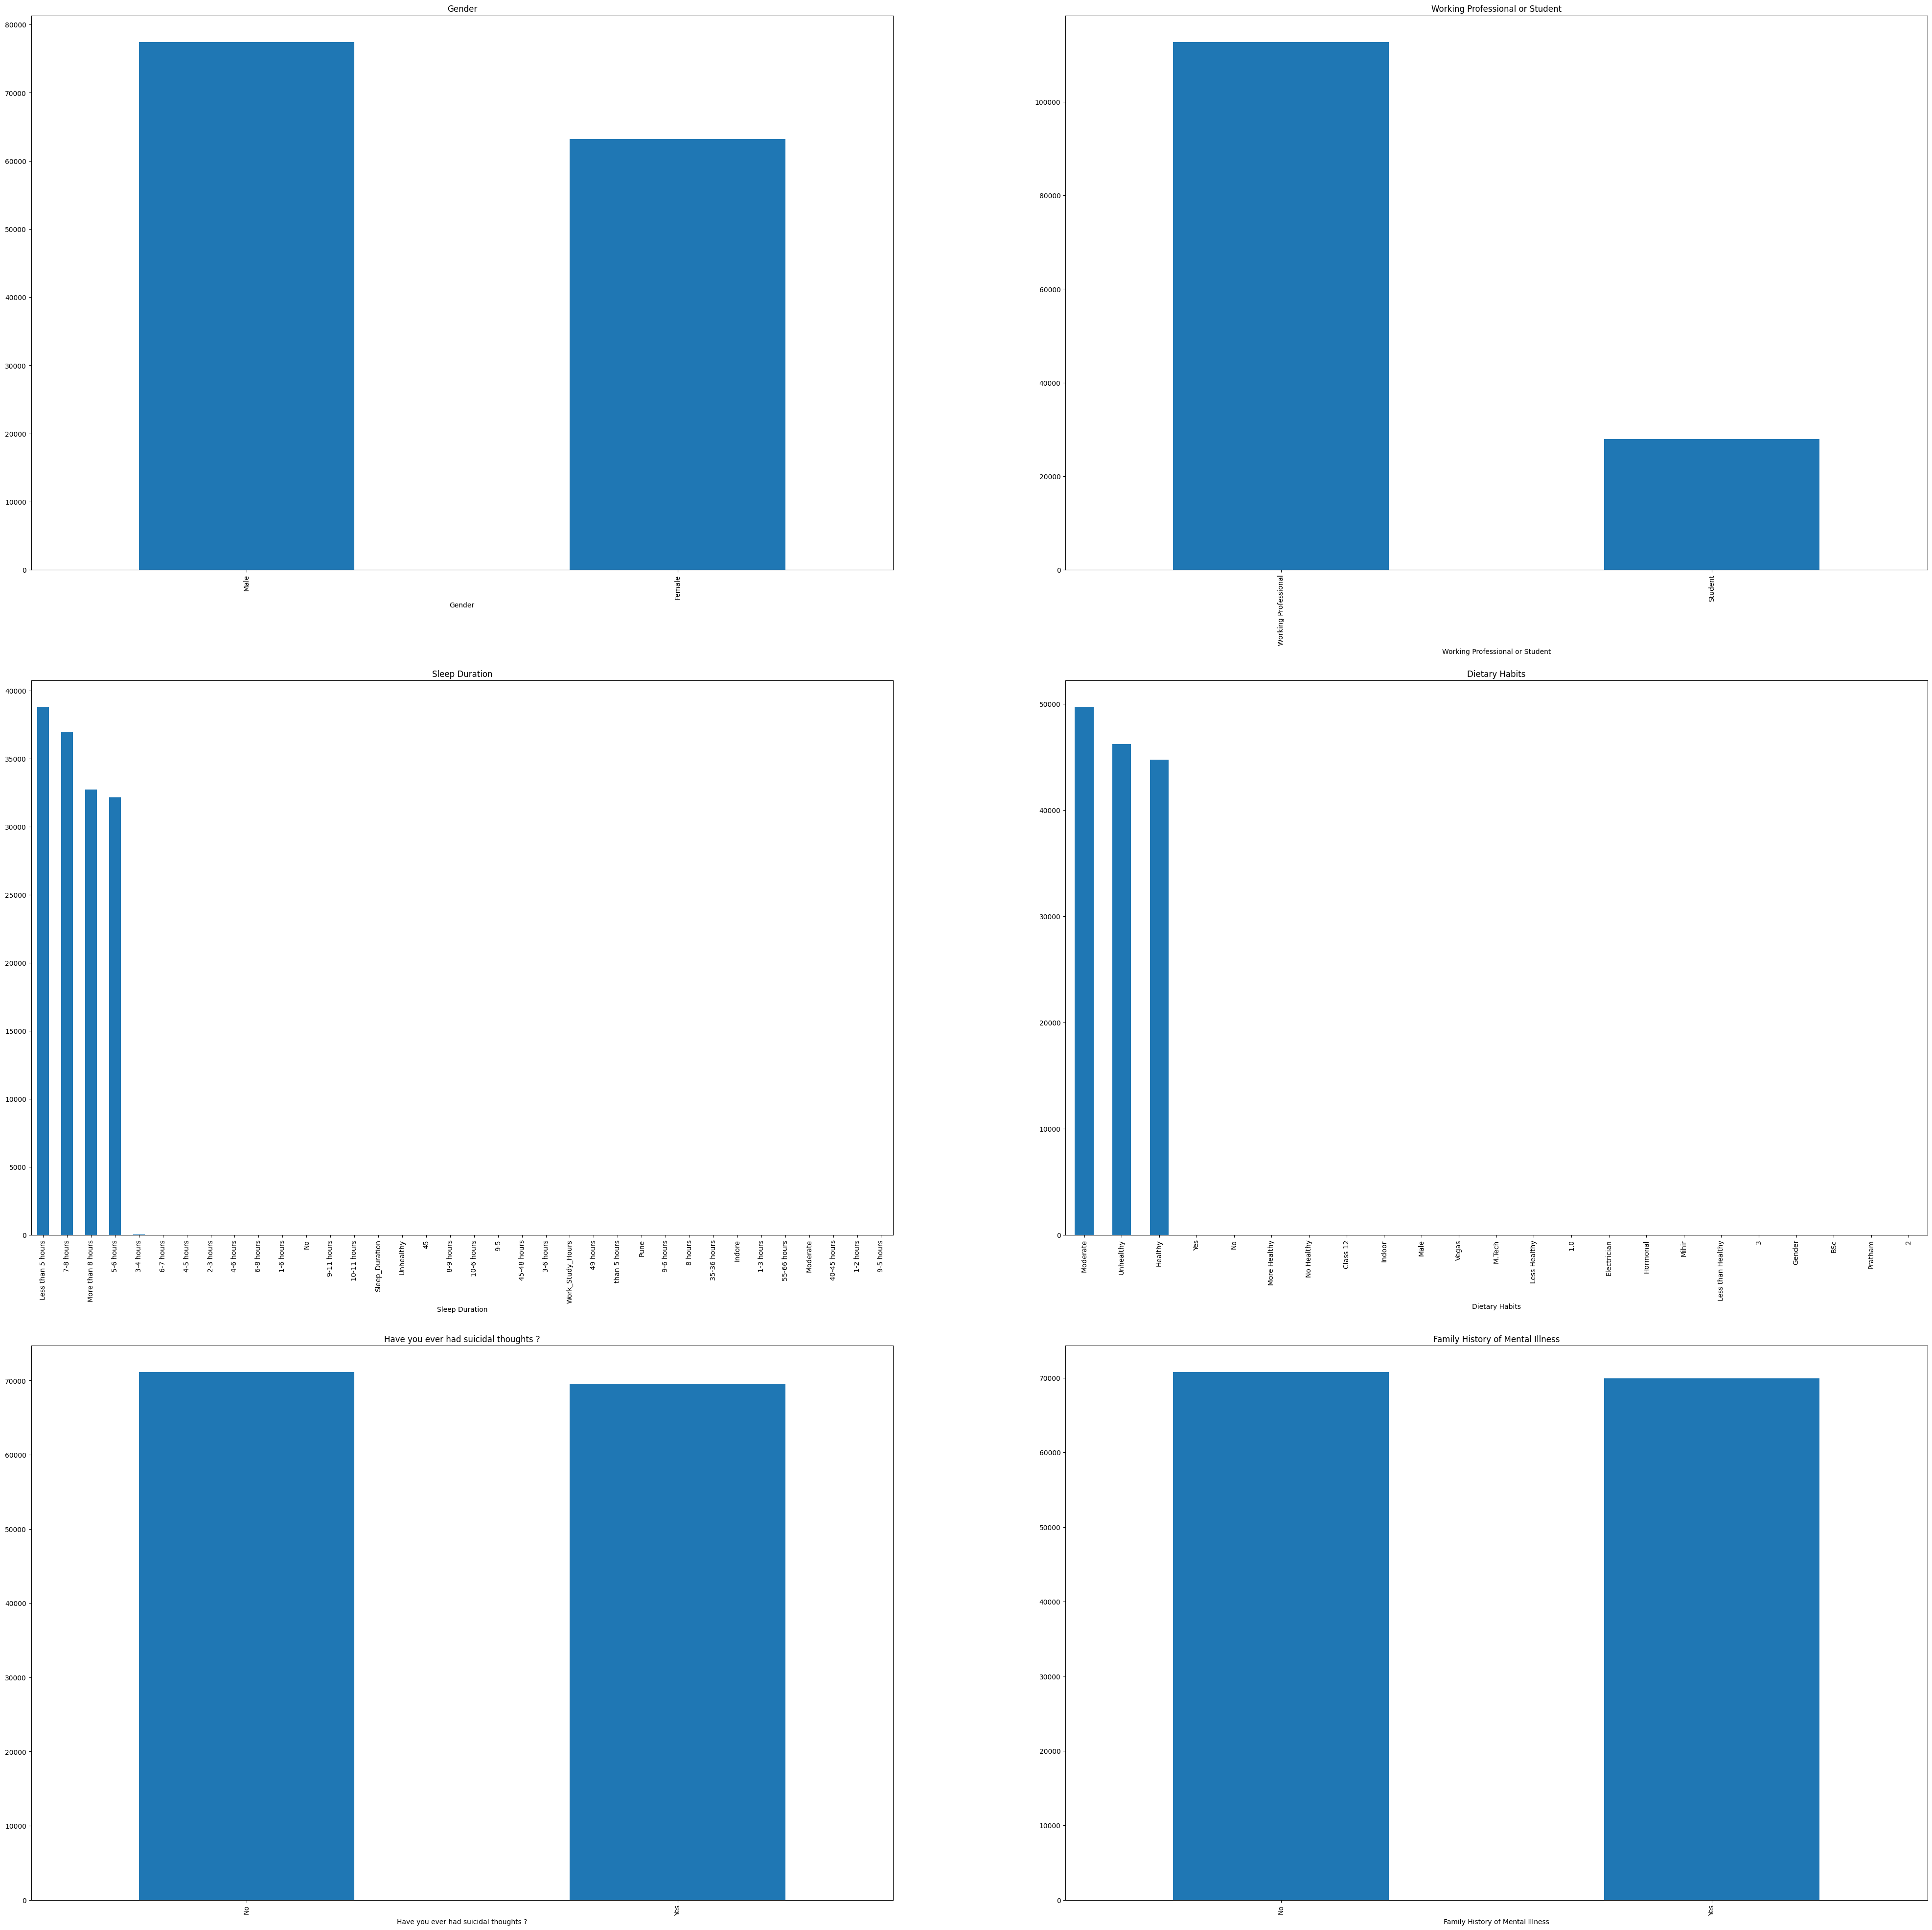

In [32]:
fig, ax = plt.subplots(3,2,figsize=(50,50))
for var, subplot in zip(categorical_vars, ax.flatten()):
    df[var].value_counts().plot(kind='bar', ax=subplot, title=var)

    fig.tight_layout

In [33]:
def identify_cat_above30(series):
    counts = series.value_counts()
    return list(counts[counts>=30].index)

In [34]:
levels_to_keep = df[categorical_vars].apply(identify_cat_above30, axis=0)
levels_to_keep

Gender                                                                      [Male, Female]
Working Professional or Student                            [Working Professional, Student]
Sleep Duration                           [Less than 5 hours, 7-8 hours, More than 8 hou...
Dietary Habits                                              [Moderate, Unhealthy, Healthy]
Have you ever had suicidal thoughts ?                                            [No, Yes]
Family History of Mental Illness                                                 [No, Yes]
dtype: object

In [36]:
for var in categorical_vars:
    df = df.loc[df[var].isin(levels_to_keep[var])]

In [37]:
df.shape

(140594, 14)

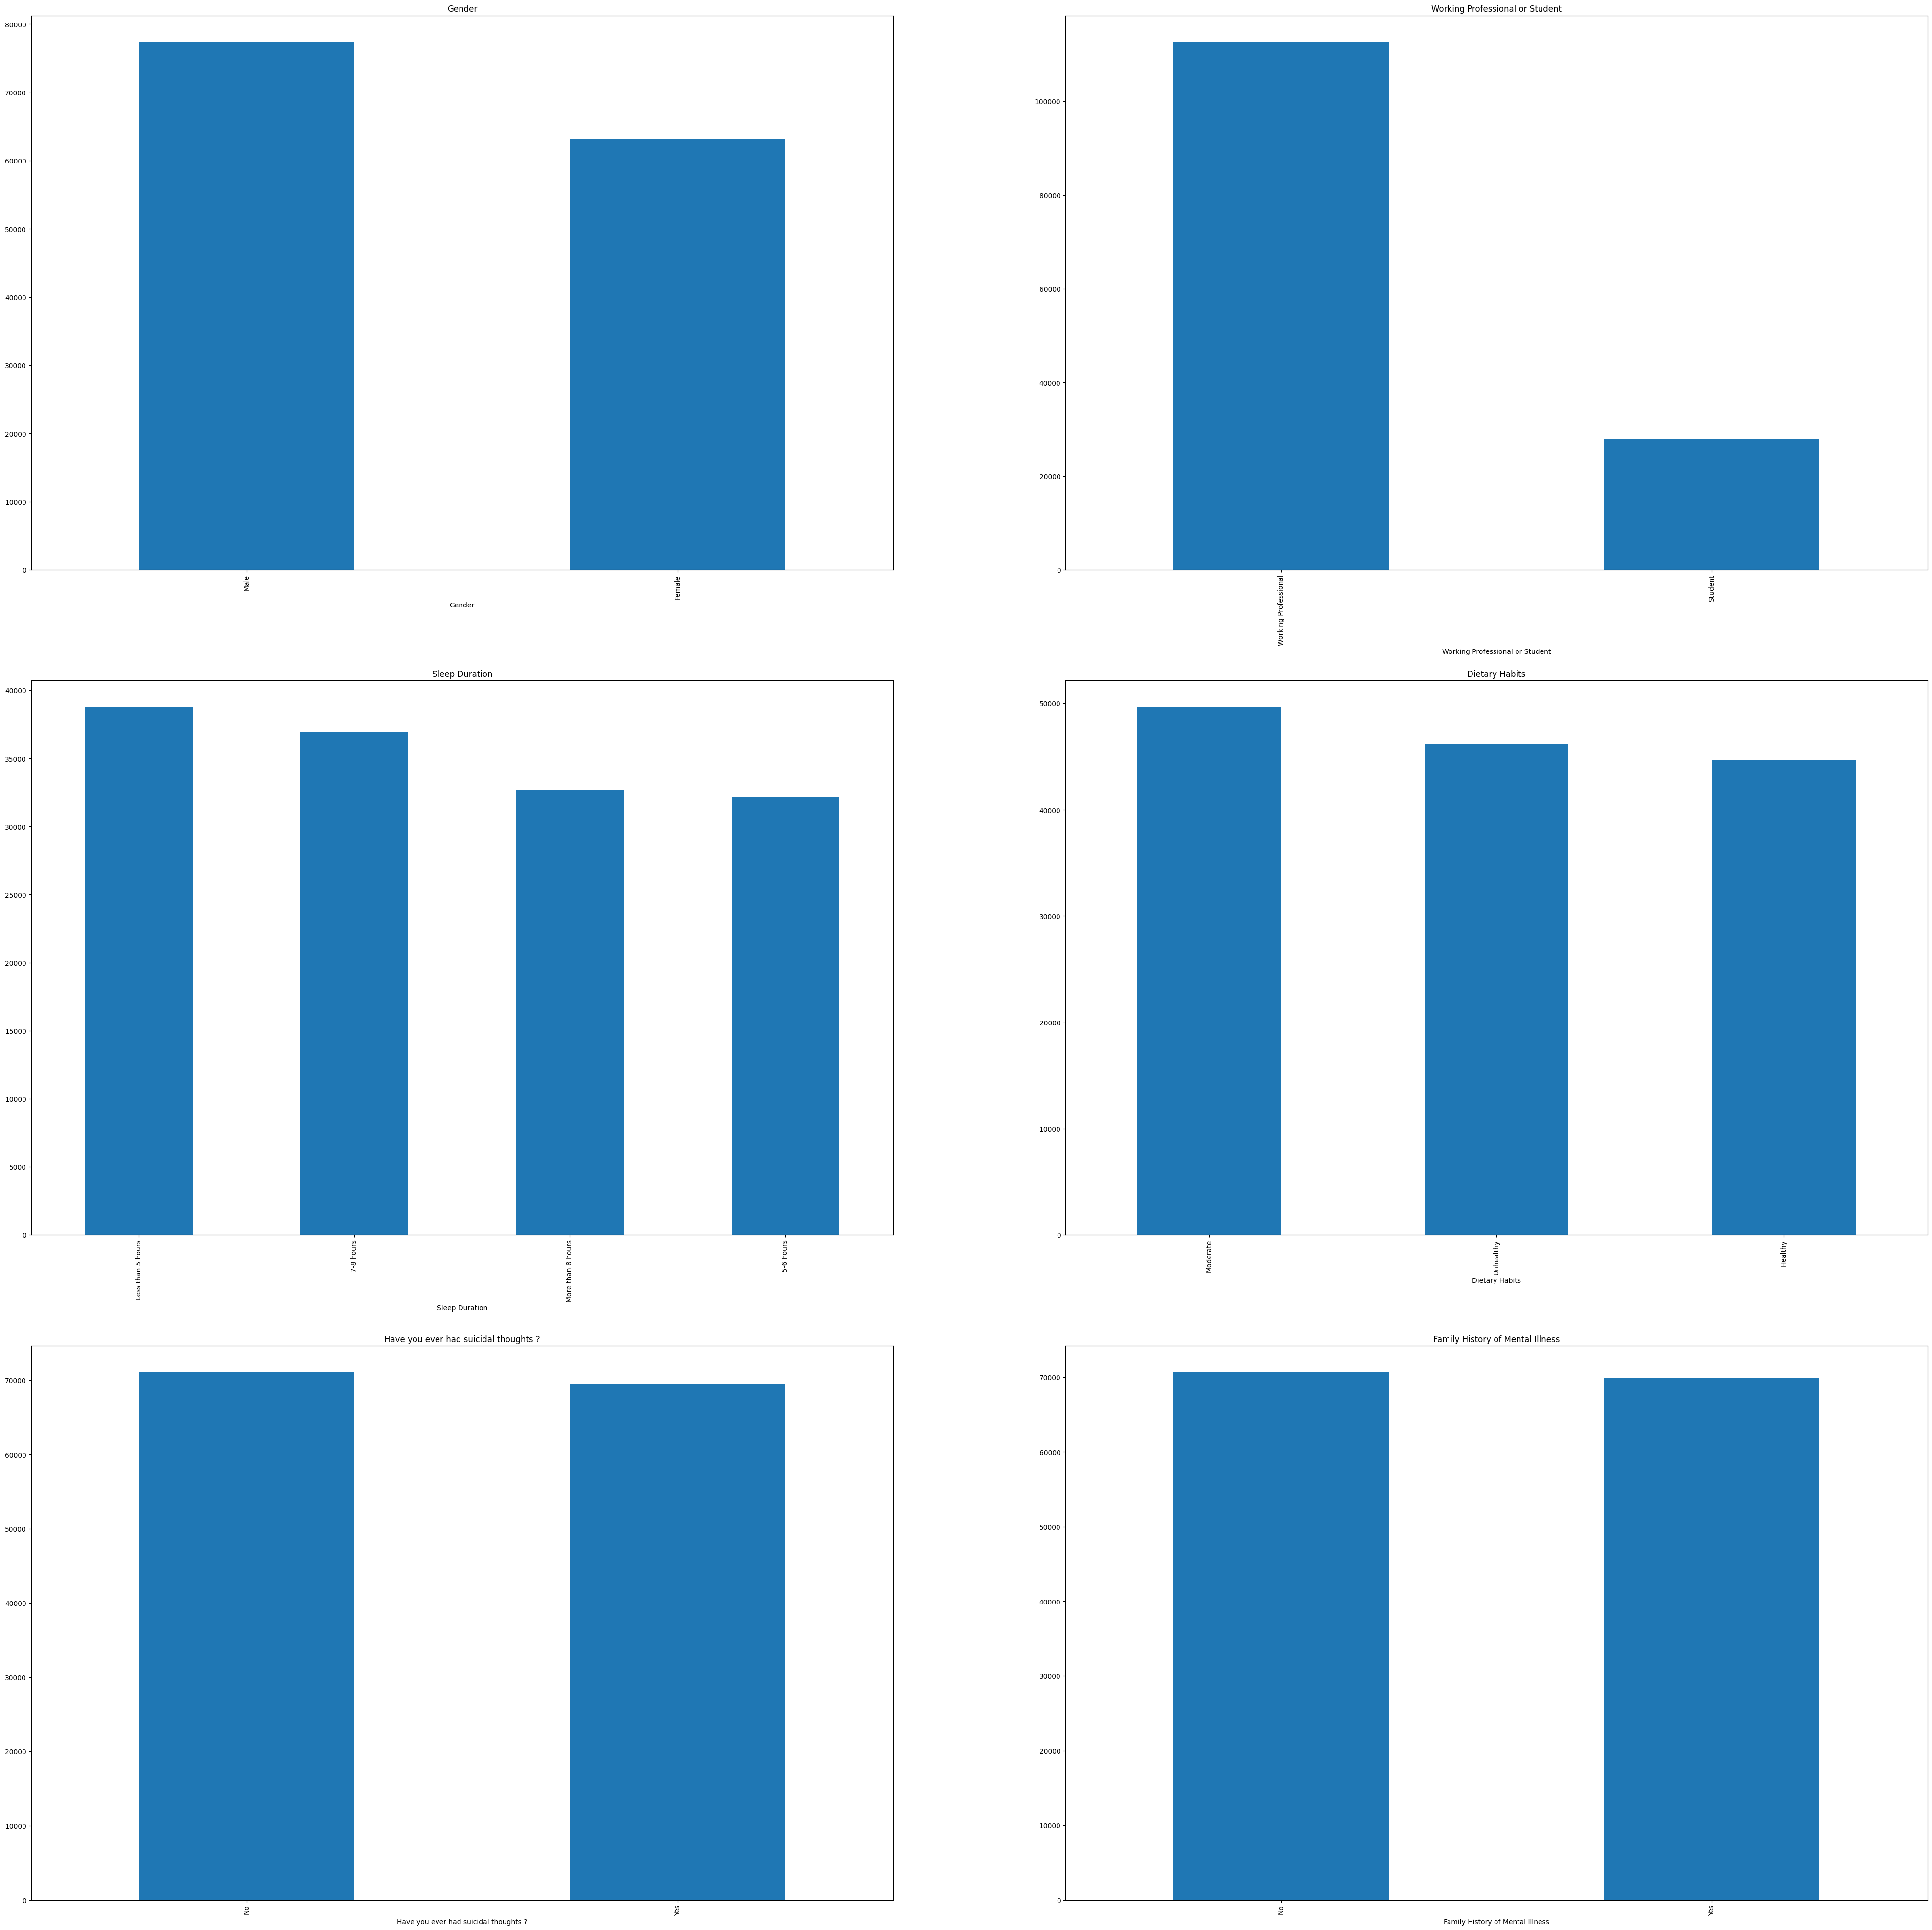

In [38]:
fig, ax = plt.subplots(3,2,figsize=(50,50))
for var, subplot in zip(categorical_vars, ax.flatten()):
    df[var].value_counts().plot(kind='bar', ax=subplot, title=var)

    fig.tight_layout

In [39]:
correlations = df[numerical_vars].corr()

<Axes: >

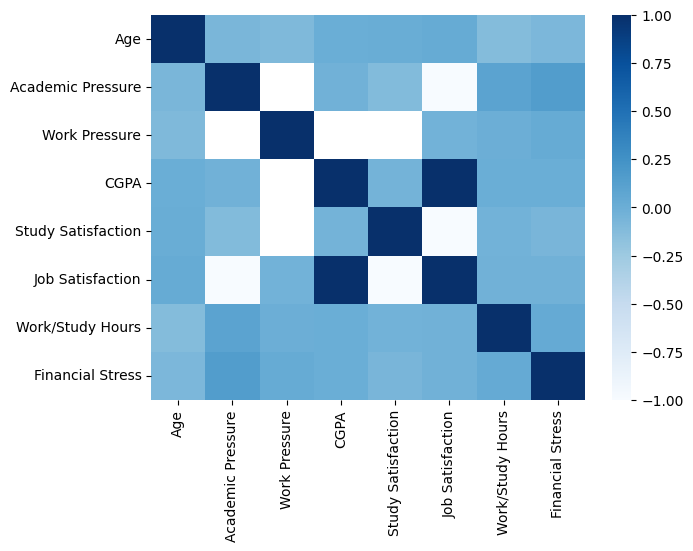

In [49]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(correlations, ax=ax, cmap='Blues')